# ResNet-18 (L1 Penalty + Dropout + TTA)

**Objective**: Based on the `penalty_experiments` series, this iteration combines the single most effective regularizerâ€”an explicit L1 penaltyâ€”with the best architectural findings (Dropout, AdamW, and Test-Time Augmentation) from Iteration 04, aiming to crush the train/val gap and set a new benchmark for ResNet-18.

**Architecture Changes**:
| Component | Previous iteration (Aug v2) | This iteration (L1 + Dropout + TTA) |
|---|---|---|
| L1 lambda | 0 | 1e-3 |
| Epochs | 20 | 30 |

**Hypothesis**: The combination of an explicit L1 penalty (which forces sparsity and aggressively combats overfitting) with Dropout and TTA (which provide inference stability) will yield the best generalization performance in the ResNet-18 series, potentially surpassing the 0.6879 Test F2 benchmark.

## Import libraries, set seed, and choose device

In [1]:
import sys
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torchvision import transforms
from PIL import Image
from sklearn.metrics import fbeta_score

ROOT = next(p for p in [Path.cwd()] + list(Path.cwd().parents) if (p / 'src').exists())
sys.path.insert(0, str(ROOT))

from src.data.dataset import HAM10000Dataset
from src.data.dataloader import get_dataloaders
from src.data.transform import get_augmented_train_transforms
from src.models.resnet import get_resnet
from src.training.trainer import train_one_epoch, validate_one_epoch
from src.utils import plot_training_curves, find_best_threshold, evaluate_model
from src.utils import seed_everything, seed_worker

import pandas as pd

g = seed_everything(42)

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Using device: {device}')

Using device: cuda


## Load and split data

In [2]:
train_dataset = HAM10000Dataset(
    csv_path=str(ROOT / 'data_new/splits/train.csv'),
    image_dir=str(ROOT / 'data_new/images/train'),
    transform=get_augmented_train_transforms(image_size=224),
)
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=4,
    persistent_workers=True,
    worker_init_fn=seed_worker,
    generator=g,
)

_, val_loader, test_loader = get_dataloaders(
    train_csv=str(ROOT / 'data_new/splits/train.csv'),
    val_csv=str(ROOT / 'data_new/splits/val.csv'),
    test_csv=str(ROOT / 'data_new/splits/test.csv'),
    image_dir=str(ROOT / 'data_new/images/train'),
    test_image_dir=str(ROOT / 'data_new/images/test'),
    batch_size=32,
    image_size=224,
    num_workers=4,
)

train_df     = pd.read_csv(ROOT / 'data_new/splits/train.csv')
num_melanoma = (train_df['label'] == 1).sum()
num_nevus    = (train_df['label'] == 0).sum()
pos_weight   = torch.tensor([num_nevus/num_melanoma], dtype=torch.float32).to(device)
print('Positive weight:', pos_weight)

Positive weight: tensor([8.1117], device='cuda:0')


## Model Definition

In [3]:
DROPOUT = 0.4
model = get_resnet(num_classes=1, freeze_backbone=False, dropout=DROPOUT).to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)

num_epochs = 25
scheduler  = CosineAnnealingLR(optimizer, T_max=num_epochs)

L1_LAMBDA = 1e-3
L2_LAMBDA = 0.0

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f'Trainable params: {trainable:,} / {total:,}')
print(f'L1 lambda: {L1_LAMBDA} | L2 lambda: {L2_LAMBDA} | Dropout: {DROPOUT}')

Trainable params: 11,177,025 / 11,177,025
L1 lambda: 0.001 | L2 lambda: 0.0 | Dropout: 0.4


## Training Loop

In [4]:
best_val_auc = 0.0
train_history, val_history = [], []

for epoch in range(num_epochs):
    train_metrics = train_one_epoch(
        model, train_loader, criterion, optimizer, device,
        l1_lambda=L1_LAMBDA, l2_lambda=L2_LAMBDA,
    )
    val_metrics = validate_one_epoch(model, val_loader, criterion, device)

    scheduler.step()

    train_history.append(train_metrics)
    val_history.append(val_metrics)

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"  Train | Loss: {train_metrics['loss']:.4f}, Bal Acc: {train_metrics['balanced_accuracy']:.4f}, Recall: {train_metrics['recall']:.4f}, F2: {train_metrics['f2']:.4f}, AUC: {train_metrics['auc']:.4f}")
    print(f"  Val   | Loss: {val_metrics['loss']:.4f}, Bal Acc: {val_metrics['balanced_accuracy']:.4f}, Recall: {val_metrics['recall']:.4f}, F2: {val_metrics['f2']:.4f}, AUC: {val_metrics['auc']:.4f}")

    if val_metrics['auc'] > best_val_auc:
        best_val_auc = val_metrics['auc']
        torch.save(model.state_dict(), ROOT / 'models/05.resnet_l1_dropout_tta_best.pth')
        print(f'  -> Saved best model (val AUC: {best_val_auc:.4f})')

Epoch [1/25]
  Train | Loss: 0.9272, Bal Acc: 0.7426, Recall: 0.8050, F2: 0.5440, AUC: 0.8161
  Val   | Loss: 0.8225, Bal Acc: 0.7682, Recall: 0.8305, F2: 0.5882, AUC: 0.8633
  -> Saved best model (val AUC: 0.8633)


Epoch [2/25]
  Train | Loss: 0.8295, Bal Acc: 0.7737, Recall: 0.8176, F2: 0.5832, AUC: 0.8556
  Val   | Loss: 0.8710, Bal Acc: 0.7623, Recall: 0.7500, F2: 0.5807, AUC: 0.8573


Epoch [3/25]
  Train | Loss: 0.8273, Bal Acc: 0.7766, Recall: 0.7856, F2: 0.5889, AUC: 0.8589
  Val   | Loss: 0.8392, Bal Acc: 0.7720, Recall: 0.7034, F2: 0.5950, AUC: 0.8729
  -> Saved best model (val AUC: 0.8729)


Epoch [4/25]
  Train | Loss: 0.8309, Bal Acc: 0.7766, Recall: 0.7788, F2: 0.5892, AUC: 0.8594
  Val   | Loss: 0.8560, Bal Acc: 0.7628, Recall: 0.6907, F2: 0.5813, AUC: 0.8681


Epoch [5/25]
  Train | Loss: 0.8255, Bal Acc: 0.7751, Recall: 0.7913, F2: 0.5863, AUC: 0.8597
  Val   | Loss: 0.8031, Bal Acc: 0.7995, Recall: 0.8093, F2: 0.6320, AUC: 0.8838
  -> Saved best model (val AUC: 0.8838)


...

Epoch [21/25]
  Train | Loss: 0.6991, Bal Acc: 0.8195, Recall: 0.8677, F2: 0.6454, AUC: 0.8993
  Val   | Loss: 0.7383, Bal Acc: 0.8031, Recall: 0.8729, F2: 0.6331, AUC: 0.8937
  -> Saved best model (val AUC: 0.8937)


Epoch [22/25]
  Train | Loss: 0.6804, Bal Acc: 0.8222, Recall: 0.8860, F2: 0.6471, AUC: 0.9028
  Val   | Loss: 0.7467, Bal Acc: 0.8014, Recall: 0.8432, F2: 0.6325, AUC: 0.8905


Epoch [23/25]
  Train | Loss: 0.6877, Bal Acc: 0.8276, Recall: 0.8814, F2: 0.6562, AUC: 0.9023
  Val   | Loss: 0.7539, Bal Acc: 0.8077, Recall: 0.8263, F2: 0.6431, AUC: 0.8920


Epoch [24/25]
  Train | Loss: 0.6537, Bal Acc: 0.8277, Recall: 0.8791, F2: 0.6567, AUC: 0.9103
  Val   | Loss: 0.7433, Bal Acc: 0.7992, Recall: 0.8602, F2: 0.6285, AUC: 0.8938
  -> Saved best model (val AUC: 0.8938)


Epoch [25/25]
  Train | Loss: 0.6488, Bal Acc: 0.8320, Recall: 0.8803, F2: 0.6633, AUC: 0.9116
  Val   | Loss: 0.7405, Bal Acc: 0.8032, Recall: 0.8559, F2: 0.6344, AUC: 0.8928


## Plot Train and Validation Curves

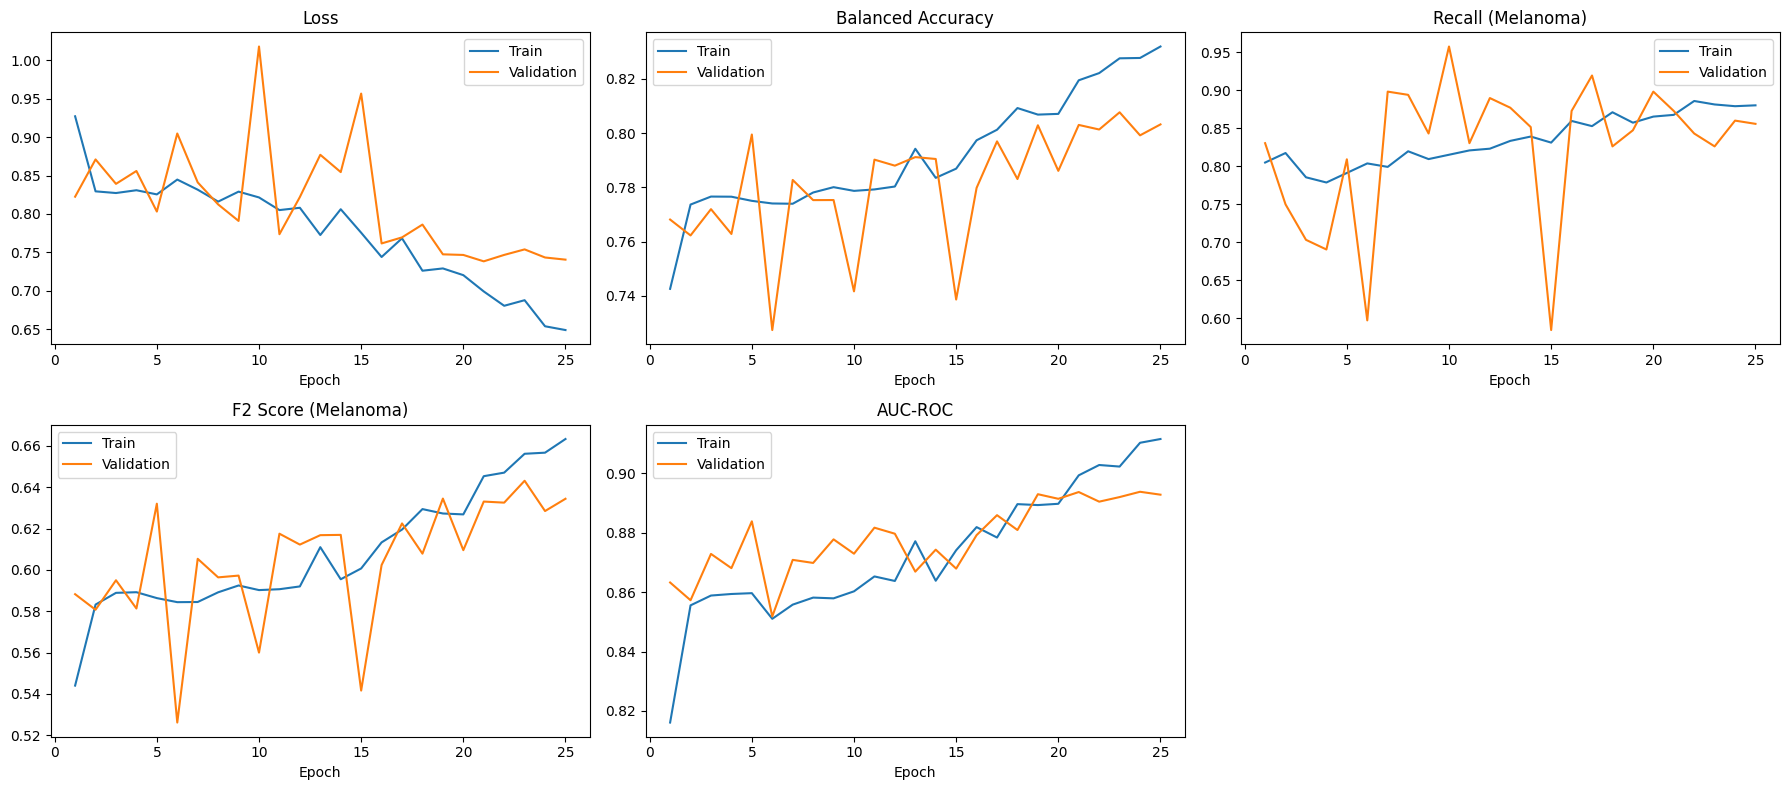

In [5]:
plot_training_curves(train_history, val_history)

## Threshold Tuning (Best Val F2)

In [6]:
model.load_state_dict(torch.load(str(ROOT / 'models/05.resnet_l1_dropout_tta_best.pth'), map_location=device))
model.eval()

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

tta_transforms = [
    transforms.Compose([transforms.Resize((224, 224)), transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)]),
    transforms.Compose([transforms.Resize((224, 224)), transforms.RandomHorizontalFlip(p=1.0), transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)]),
    transforms.Compose([transforms.Resize((224, 224)), transforms.RandomVerticalFlip(p=1.0), transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)]),
    transforms.Compose([transforms.Resize((224, 224)), transforms.RandomHorizontalFlip(p=1.0), transforms.RandomVerticalFlip(p=1.0), transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)]),
    transforms.Compose([transforms.Resize((224, 224)), transforms.RandomRotation(degrees=(90, 90)), transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)]),
    transforms.Compose([transforms.Resize((224, 224)), transforms.RandomRotation(degrees=(180, 180)), transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)]),
    transforms.Compose([transforms.Resize((224, 224)), transforms.RandomRotation(degrees=(270, 270)), transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)]),
    transforms.Compose([transforms.Resize((224, 224)), transforms.RandomRotation(degrees=(45, 45)), transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)]),
]

def tta_predict(model, dataset, device, tta_transforms):
    all_probs = []
    all_labels = []
    for idx in range(len(dataset)):
        image_id = dataset.data.iloc[idx]['image_id']
        label = int(dataset.data.iloc[idx]['label'])
        img = Image.open(dataset.image_dir / (image_id + '.jpg')).convert('RGB')
        preds = []
        with torch.no_grad():
            for t in tta_transforms:
                tensor = t(img).unsqueeze(0).to(device)
                prob = torch.sigmoid(model(tensor)).item()
                preds.append(prob)
        all_probs.append(np.mean(preds))
        all_labels.append(label)
    return np.array(all_probs), np.array(all_labels)

print("Running TTA on validation set...")
val_probs, val_labels = tta_predict(model, val_loader.dataset, device, tta_transforms)

thresholds = np.arange(0.01, 0.9, 0.01)
f2_scores = [fbeta_score(val_labels, (val_probs >= t).astype(int), beta=2, pos_label=1, zero_division=0) for t in thresholds]
best_threshold = thresholds[np.argmax(f2_scores)]
print(f"Best threshold: {best_threshold:.2f} | Val F2: {max(f2_scores):.4f}")

Running TTA on validation set...
Best threshold: 0.68 | Val F2: 0.6505


## Test Set Evaluation

In [7]:
from src.utils import evaluate_model
from sklearn.metrics import roc_auc_score, balanced_accuracy_score, classification_report

print("Running TTA on test set...")
test_probs, test_labels = tta_predict(model, test_loader.dataset, device, tta_transforms)
all_preds = (test_probs >= best_threshold).astype(int)

auc     = roc_auc_score(test_labels, test_probs)
bal_acc = balanced_accuracy_score(test_labels, all_preds)
f2      = fbeta_score(test_labels, all_preds, beta=2, pos_label=1, zero_division=0)

print(f"Threshold:          {best_threshold:.2f}")
print(f"AUC-ROC:            {auc:.4f}")
print(f"Balanced Accuracy:  {bal_acc:.4f}")
print(f"F2 Score:           {f2:.4f}")
print()
print(classification_report(test_labels, all_preds, target_names=["Non-Melanoma", "Melanoma"], digits=4))

Running TTA on test set...
Threshold:          0.68
AUC-ROC:            0.9090
Balanced Accuracy:  0.8111
F2 Score:           0.6507

              precision    recall  f1-score   support

Non-Melanoma     0.9657    0.8619    0.9109      1340
    Melanoma     0.4127    0.7602    0.5350       171

    accuracy                         0.8504      1511
   macro avg     0.6892    0.8111    0.7229      1511
weighted avg     0.9031    0.8504    0.8683      1511

